# Intro

In [17]:
# jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_num_cpu_devices", NUM_CPU_DEVICES)
import copy
import multiprocessing
import os
import time
from functools import partial
from pathlib import Path
from typing import Callable

import equinox as eqx
import gstools as gs
import imageio_ffmpeg

# Tell JAX to create 8 logical CPU devices (e.g., if you have an 8-core CPU)
# IMPORTANT: This must be run before you import JAX!
# NUM_CPU_DEVICES = multiprocessing.cpu_count()
# os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={NUM_CPU_DEVICES}"
import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.animation as animation
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from einops import rearrange, reduce, repeat
from IPython.display import HTML
from jax.experimental import checkify
from jax_tqdm import scan_tqdm
from scipy.io import loadmat
from statsmodels.tsa.stattools import acf
from tqdm.auto import tqdm, trange

from nanopinv.distribution import MultivariateNormalCholesky
from nanopinv.physics_jax import build_travel_time_points
from nanopinv.sampler_jax import (
    ExtendedMetropolisChain,
    History,
    IterationState,
    ParallelTemperingSampler,
    ProposalDistribution,
    initialize_betas,
)
from nanopinv.types import Observations
from nanopinv.utils import StatefulRNGKey, make_pytree_spec
from nanopinv.variance import get_distance_matrix, spherical

mpl.rcParams["animation.ffmpeg_path"] = imageio_ffmpeg.get_ffmpeg_exe()

PROGRESS = True

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
# Load dataset
M = loadmat("AM13_data.mat")

N_data, N_dim = M["S"].shape
sources = jnp.asarray(M["S"])  # Shape: (N_data, N_dim)
receivers = jnp.asarray(M["R"])  # Shape: (N_data, N_dim)
assert sources.shape == receivers.shape, (
    "Sources and receivers must have the same shape."
)

data_obs = M["d_obs"].flatten()
data_std = M["d_std"].flatten()
data_std = 0.4 * np.ones_like(
    data_obs
)  # For whatever reason, we overwrite this, maybe original data was wrong?

print(f"Number of data points: {N_data}")
print(f"Number of dimensions: {N_dim}")

Number of data points: 702
Number of dimensions: 2


In [11]:
# Set up grid
dx = 0.135
x = jnp.arange(-2 * dx, 5 + 2 * dx, dx)
y = jnp.arange(1 - 2 * dx, 12 + 2 * dx, dx)
r = (
    x,
    y,
)
grid_shape = (
    len(x),
    len(y),
)

# Set up prior
m0 = 0.12
range_ = 7.0
partial_sill = 0.00003
nugget = 1e-10

h = get_distance_matrix(*r)
cov = spherical(h, range_=range_, partial_sill=partial_sill, nugget=nugget)
prior = MultivariateNormalCholesky(shape=grid_shape, cov=cov, mean=m0)

# Set up forward model
forward_model = build_travel_time_points(sources, receivers, x, y, solver="solver3")

# Set up proposal distribution
proposal_dist = ProposalDistribution(dist=prior, step_size=0.1)

# Set up observations
obs = Observations(
    data_obs=data_obs,
    data_std=data_std,
)
\
# Set up RNG
skey = StatefulRNGKey(0)


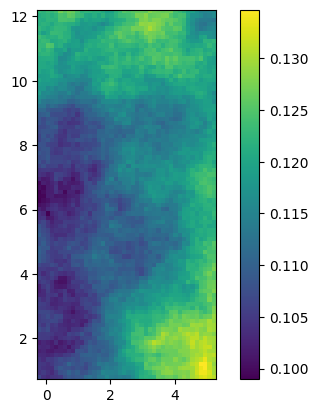

In [12]:
realisation = prior(skey())

plt.imshow(
    realisation.T, extent=(x[0], x[-1], y[0], y[-1]), origin="lower", cmap=cm.viridis
)
plt.colorbar()

In [13]:
@jax.jit
def log_likelihood_gaussian(data, data_obs, data_std):
    normalised_residual = (data_obs - data) / data_std
    log_likelihood = -0.5 * jnp.sum(normalised_residual**2)
    return jnp.sum(log_likelihood)


chain = ExtendedMetropolisChain(
    beta=1.0,
    proposal_dist=proposal_dist,
    forward_model=forward_model,
    log_likelihood_fn=log_likelihood_gaussian,
)

In [14]:
N_chains = 3
betas = initialize_betas(n_chains=3)
N_steps = 250

chain_spec = make_pytree_spec(
    chain,
    {
        "beta": 0,
        "proposal_dist.step_size": 0,
        "*": None,
    },
)
@eqx.filter_vmap(in_axes=(0,), out_axes=chain_spec)
def setup_chains(betas):
    return ExtendedMetropolisChain(
        beta=betas,
        proposal_dist=proposal_dist,
        forward_model=forward_model,
        log_likelihood_fn=log_likelihood_gaussian,
    )

@eqx.filter_vmap(in_axes=(0, chain_spec, None))
def get_iteration_state(key, chains, obs):
    return chains.get_iteration_state(
        prior(key), obs
    )

chains = setup_chains(betas)
iter_state_current = get_iteration_state(skey(n=N_chains), chains, obs)

iter_state_current


IterationState(state=f32[3,42,86], log_likelihood=f32[3])

In [15]:
chains

ExtendedMetropolisChain(
  beta=f32[3],
  proposal_dist=ProposalDistribution(
    dist=MultivariateNormalCholesky(
      mean=weak_f32[1], shape=(42, 86), L=f32[3612,3612]
    ),
    step_size=weak_f32[3],
    mean=weak_f32[1]
  ),
  forward_model=<PjitFunction>,
  log_likelihood_fn=<PjitFunction of <function log_likelihood_gaussian at 0x7b22a0390a90>>
)

In [16]:
# Tune
N_steps_tune = 500
tune_interval = 100
keep_interval = 10

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(chain_spec, 0, 0), out_axes=(chain_spec, 0, 0))
def get_tuner(chains, key, iter_state):
    return chains.tune(
        n_steps_tune=N_steps_tune,
        tune_interval=tune_interval,
        key=key,
        iter_state=iter_state,
        observations=obs,
        progress=True,
    )

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(None, 0, chain_spec, 0, None))
def step_n_chains(N_steps, key, chains, iter_state, keep_interval):
    return chains.step_n(
        N_steps,
        key=key,
        iter_state=iter_state,
        observations=obs,
        progress=PROGRESS,
        keep_interval=keep_interval,
    )

# Chains

In [46]:
tuned_chains, tuned_iter_state, tune_history = get_tuner(chains, skey(n=N_chains), iter_state_current)

(JitTracer(int32[500]), IterationState(state=f32[500,42,86], log_likelihood=f32[500]), JitTracer(~float32[500]), JitTracer(float32[500]))


Tuning:   0%|          | 0/500 [00:00<?, ?it/s]

In [47]:
len(tune_history)
tune_history

(Array([[  1,   2,   3, ..., 498, 499, 500],
        [  1,   2,   3, ..., 498, 499, 500],
        [  1,   2,   3, ..., 498, 499, 500]], dtype=int32),
 IterationState(state=f32[3,500,42,86], log_likelihood=f32[3,500]),
 Array([[0.1       , 0.1       , 0.1       , ..., 0.13826403, 0.13826403,
         0.13826403],
        [0.1       , 0.1       , 0.1       , ..., 0.14643277, 0.14643277,
         0.14643277],
        [0.1       , 0.1       , 0.1       , ..., 0.8071528 , 0.8071528 ,
         0.8071528 ]], dtype=float32, weak_type=True),
 Array([[1., 1., 0., ..., 0., 0., 0.],
        [1., 0., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 1., 1., 1.]], dtype=float32))

In [48]:

n_steps_iter_state, n_steps_history = step_n_chains(
    N_steps, skey(N_chains), tuned_chains, iter_state_current, keep_interval
)


Sampling:   0%|          | 0/250 [00:00<?, ?it/s]

In [35]:
# Batched chains
N_batch = 5

chain_spec_batch = make_pytree_spec(
    chain,
    {
        "*": None,
    },
)
chain_spec = make_pytree_spec(
    chain,
    {
        "beta": 0,
        "proposal_dist.step_size": 0,
        "*": None,
    },
)

@eqx.filter_vmap(in_axes=(None, None,), out_axes=chain_spec_batch)
@eqx.filter_vmap(in_axes=(0, 0,), out_axes=chain_spec)
def setup_chains_batch(betas, step_sizes):
    proposal_dist = ProposalDistribution(dist=prior, step_size=step_sizes)

    return ExtendedMetropolisChain(
        beta=betas,
        proposal_dist=proposal_dist,
        forward_model=forward_model,
        log_likelihood_fn=log_likelihood_gaussian,
    )

@eqx.filter_vmap(in_axes=(0, chain_spec_batch, None))
@eqx.filter_vmap(in_axes=(0, chain_spec, None))
def get_iteration_state(key, chains, obs):
    return chains.get_iteration_state(
        prior(key), obs
    )

chains_batch = setup_chains_batch(tuned_chains.beta, tuned_chains.proposal_dist.step_size)
iter_state_current_batch = get_iteration_state(skey.shaped((N_batch, N_chains)), chains_batch, obs)

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(None, 0, chain_spec_batch, 0, None))
@eqx.filter_vmap(in_axes=(None, 0, chain_spec, 0, None))
def step_n_chains_batch(N_steps, key, chains, iter_state, keep_interval):
    return chains.step_n(
        N_steps,
        key=key,
        iter_state=iter_state,
        observations=obs,
        progress=PROGRESS,
        keep_interval=keep_interval,
    )


n_steps_iter_state_batch, n_steps_history_batch = step_n_chains_batch(
    N_steps, skey.shaped((N_batch, N_chains)), chains_batch, iter_state_current_batch, keep_interval
)


Sampling:   0%|          | 0/250 [00:00<?, ?it/s]

In [36]:
display(n_steps_history._get_log_likelihoods().shape)
display(n_steps_history_batch._get_log_likelihoods().shape)

NameError: name 'n_steps_history' is not defined

In [ ]:
def take_first(tensor, axis):
    # Sort in reverse to prevent axis shifting as dimensions are dropped
    for ax in sorted(axis, reverse=True):
        tensor = jnp.take(tensor, 0, axis=ax)

    return tensor

reduce(n_steps_history.iterations, "... n_chains n_saved-> (... n_chains) n_saved", take_first).shape
reduce(n_steps_history_batch.iterations, "... n_chains n_saved-> n_saved", take_first).shape

(25,)

In [ ]:
n_steps_history._get_iterations()

Array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100, 110, 120, 130,
       140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250],      dtype=int32)

(3,)

<Axes: title={'center': 'Log-Likelihood Trace'}, xlabel='MCMC Step', ylabel='Log-likelihood'>

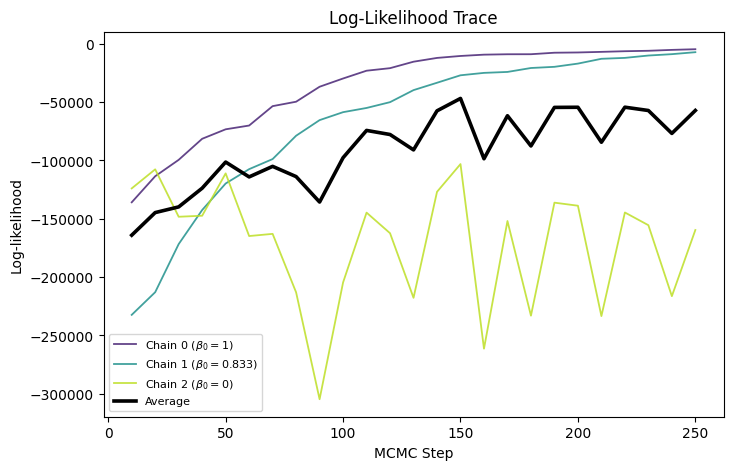

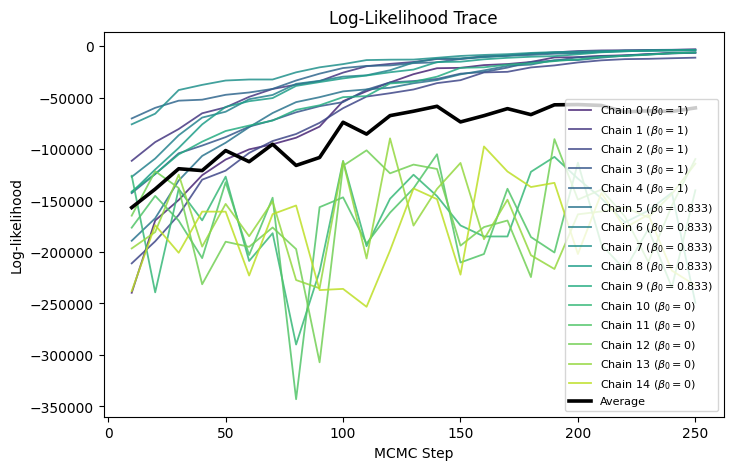

In [ ]:
display(n_steps_history.betas.shape)
n_steps_history.plot_log_likelihoods()
n_steps_history_batch.plot_log_likelihoods()

(3,)

<Axes: title={'center': 'Log-Likelihood Autocorrelation'}, xlabel='Lag', ylabel='ACF'>

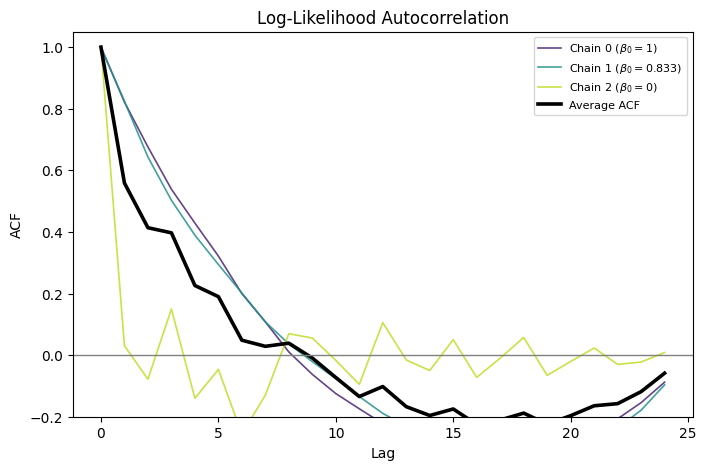

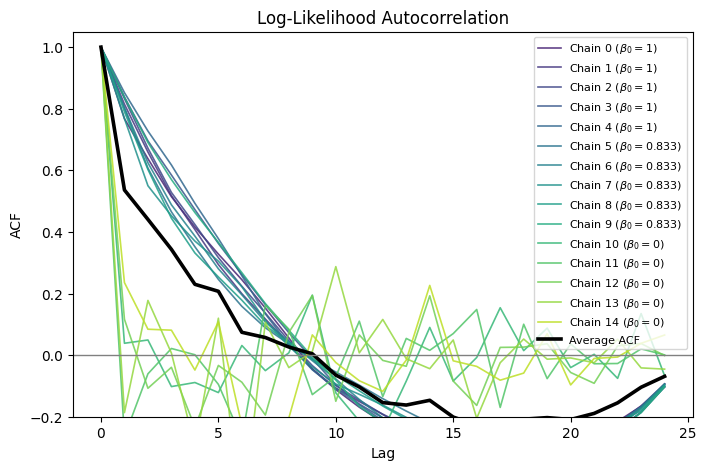

In [ ]:
display(n_steps_history.betas.shape)
n_steps_history.plot_autocorrelation()
n_steps_history_batch.plot_autocorrelation()

(3,)

<Axes: title={'center': 'Within-Chain Acceptance (Window=1)'}, xlabel='MCMC Step', ylabel='Acceptance rate'>

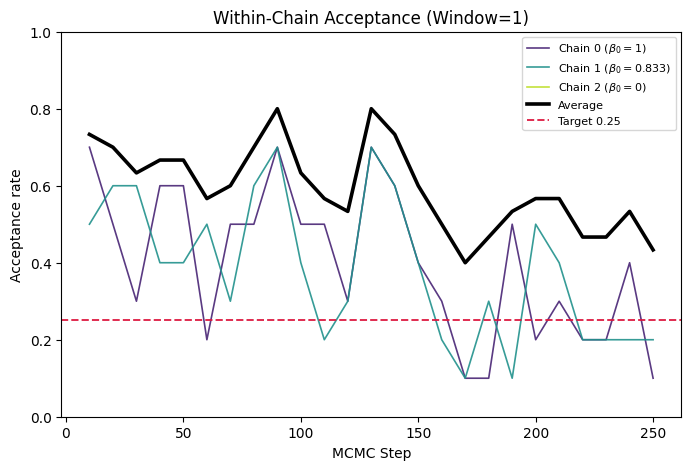

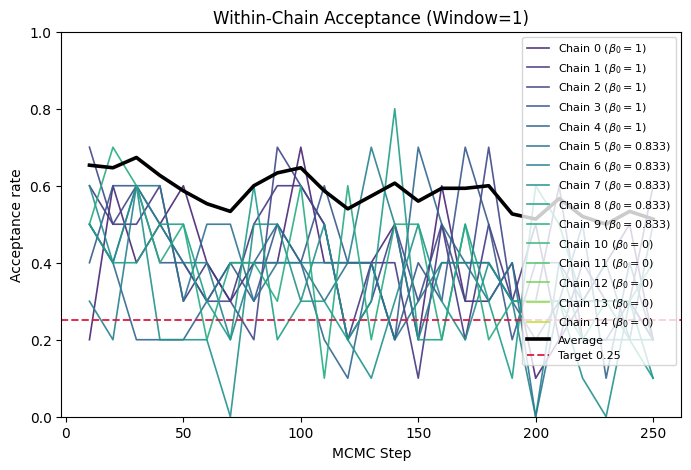

In [ ]:
display(n_steps_history.betas.shape)
n_steps_history.plot_local_acceptance(window=1)
n_steps_history_batch.plot_local_acceptance(window=1)

(3,)

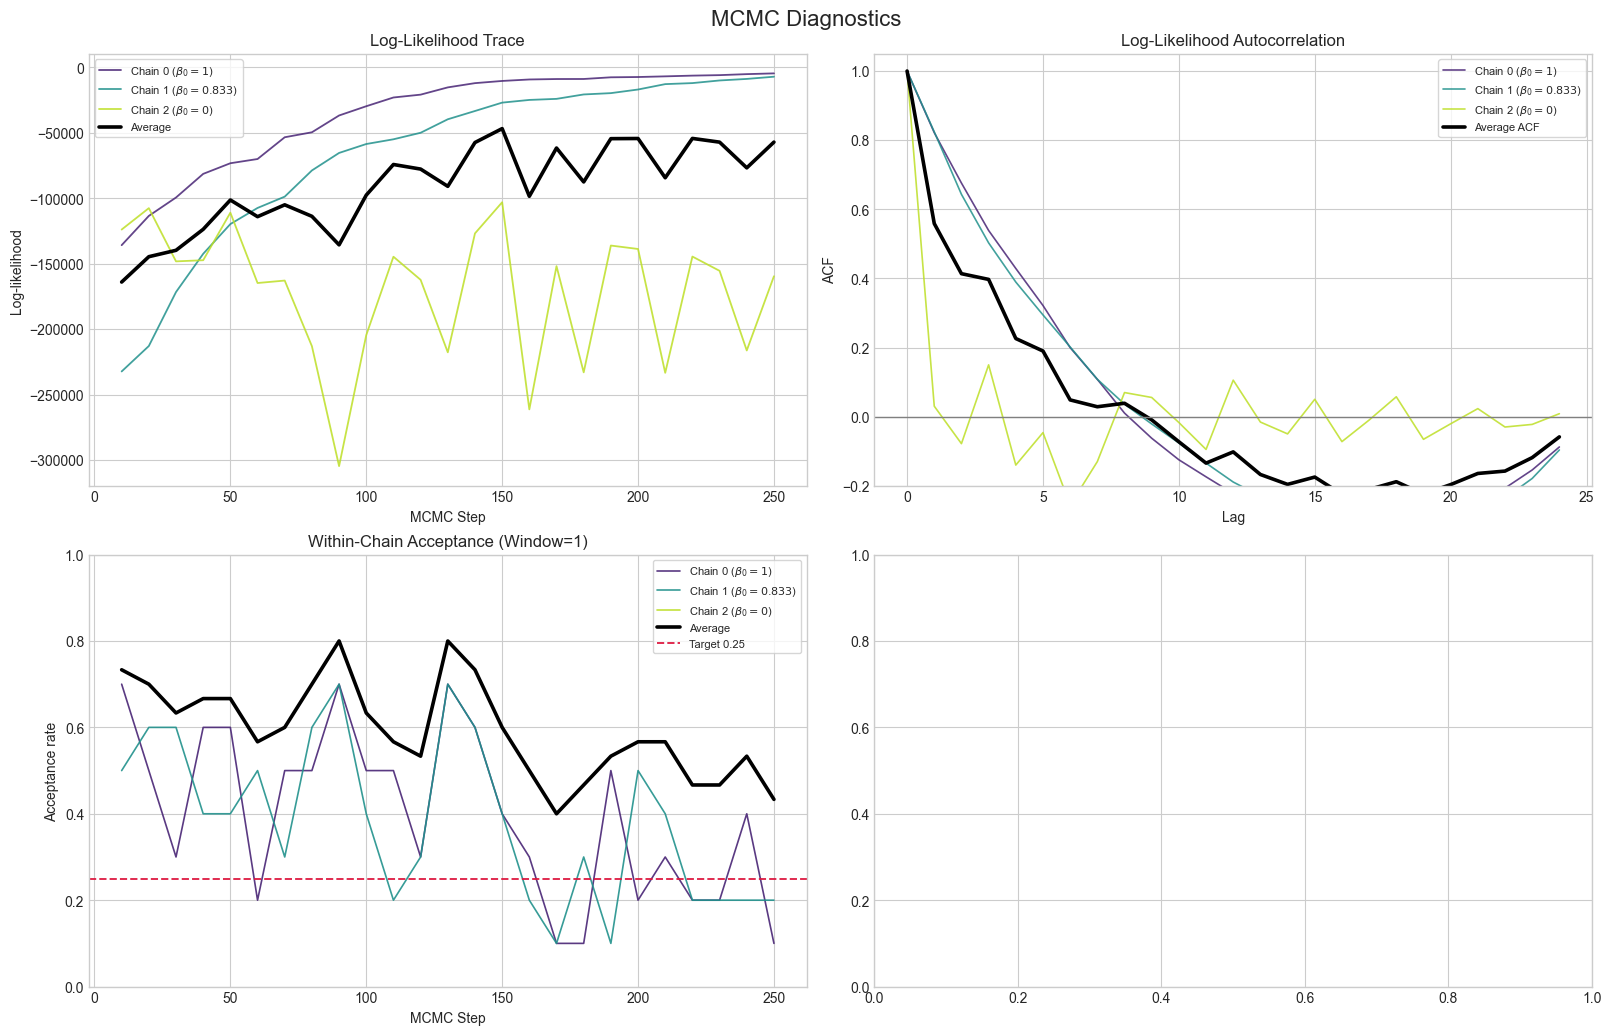

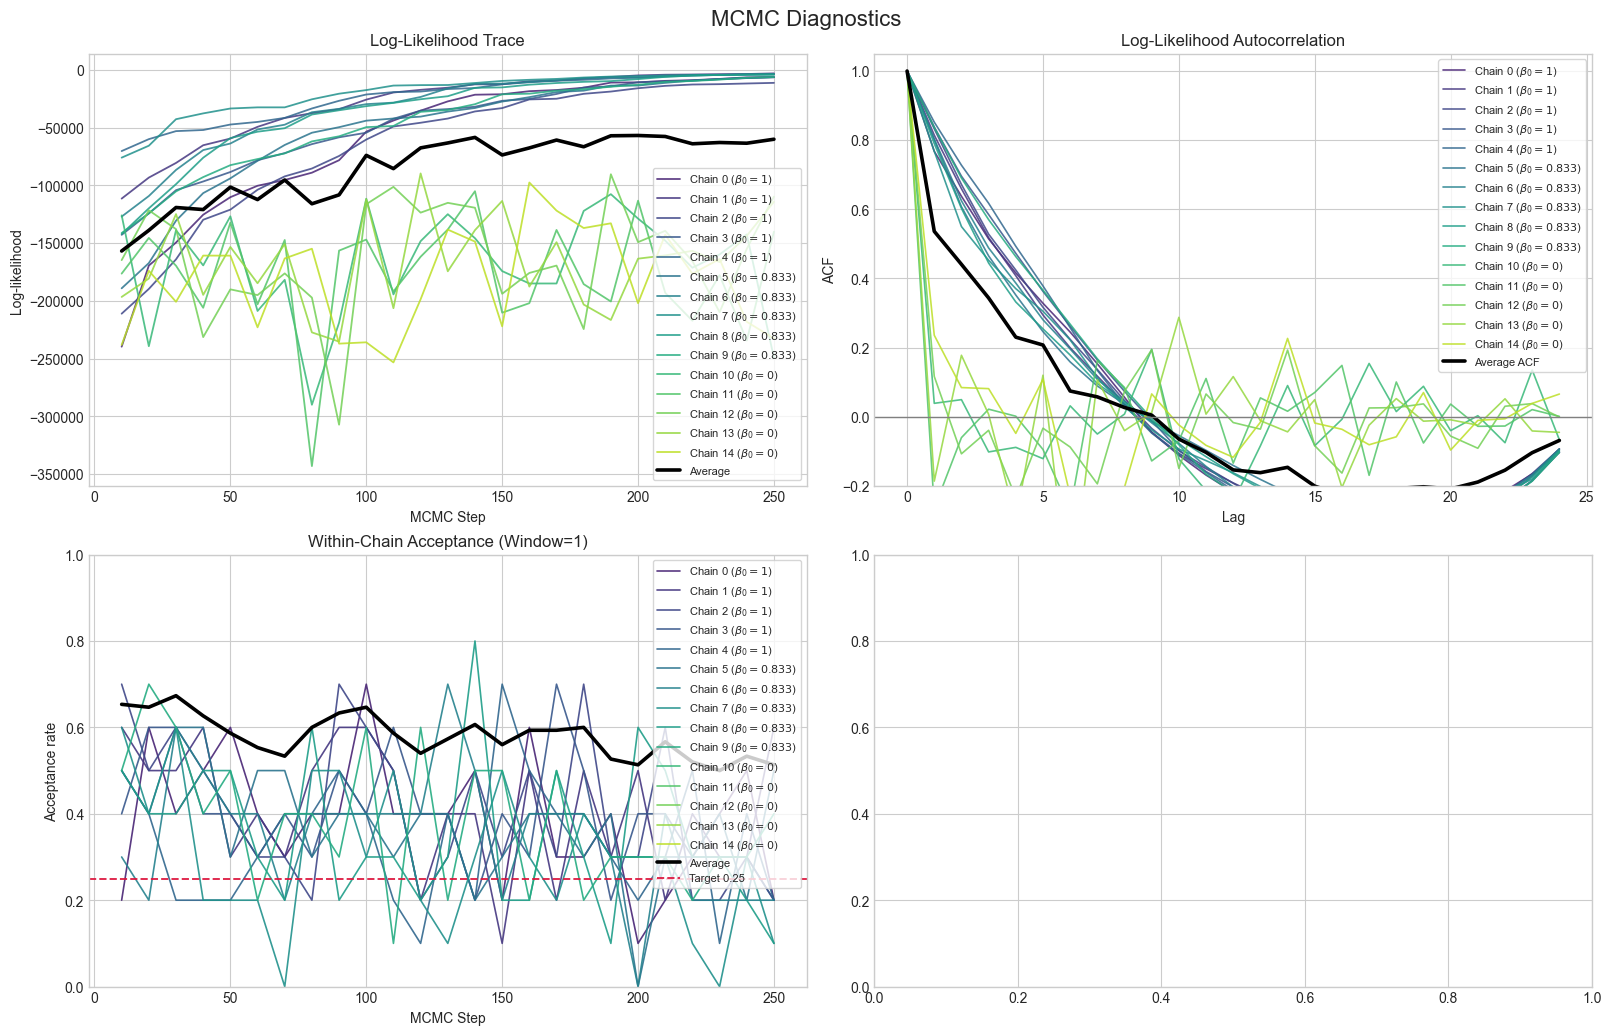

(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Log-Likelihood Trace'}, xlabel='MCMC Step', ylabel='Log-likelihood'>,
         <Axes: title={'center': 'Log-Likelihood Autocorrelation'}, xlabel='Lag', ylabel='ACF'>],
        [<Axes: title={'center': 'Within-Chain Acceptance (Window=1)'}, xlabel='MCMC Step', ylabel='Acceptance rate'>,
         <Axes: >]], dtype=object))

In [ ]:
display(n_steps_history.betas.shape)
n_steps_history.plot_diagnostics(window=1)
n_steps_history_batch.plot_diagnostics(window=1)

In [ ]:
tune_history

(Array([[  1,   2,   3, ..., 498, 499, 500],
        [  1,   2,   3, ..., 498, 499, 500],
        [  1,   2,   3, ..., 498, 499, 500]], dtype=int32),
 IterationState(state=f32[3,500,42,86], log_likelihood=f32[3,500]),
 Array([[0.1       , 0.1       , 0.1       , ..., 0.13826403, 0.13826403,
         0.13826403],
        [0.1       , 0.1       , 0.1       , ..., 0.14643277, 0.14643277,
         0.14643277],
        [0.1       , 0.1       , 0.1       , ..., 0.8071528 , 0.8071528 ,
         0.8071528 ]], dtype=float32, weak_type=True),
 Array([[1., 1., 0., ..., 0., 0., 0.],
        [1., 0., 1., ..., 0., 0., 0.],
        [1., 1., 1., ..., 1., 1., 1.]], dtype=float32))

In [ ]:
n_steps_history.iterand_n_accepted.shape
n_steps_history_batch.iterand_n_accepted.shape

(5, 3, 25)

In [ ]:
n_steps_history._get_betas().shape
# n_steps_history_batch._get_betas().shape

(3, 25)

In [ ]:
n_steps_history.betas.shape

(3,)

In [ ]:
*chain_batches, a, n_saved = n_steps_history.states.log_likelihood.shape
chain_batches, a, n_saved

([], 3, 25)

In [ ]:
repeat(jnp.asarray([1]), "s -> (n_chains s)", n_chains=3)

Array([1, 1, 1], dtype=int32)

In [ ]:
n_steps_history.temperatures

Array([1.       , 0.8333333, 0.       ], dtype=float32)

In [ ]:
*chain_batches, n_saved = n_steps_history_batch.states.log_likelihood.shape
chain_batches

[5, 3]

In [ ]:
n_steps_history.states.log_likelihood.shape

(3, 25)

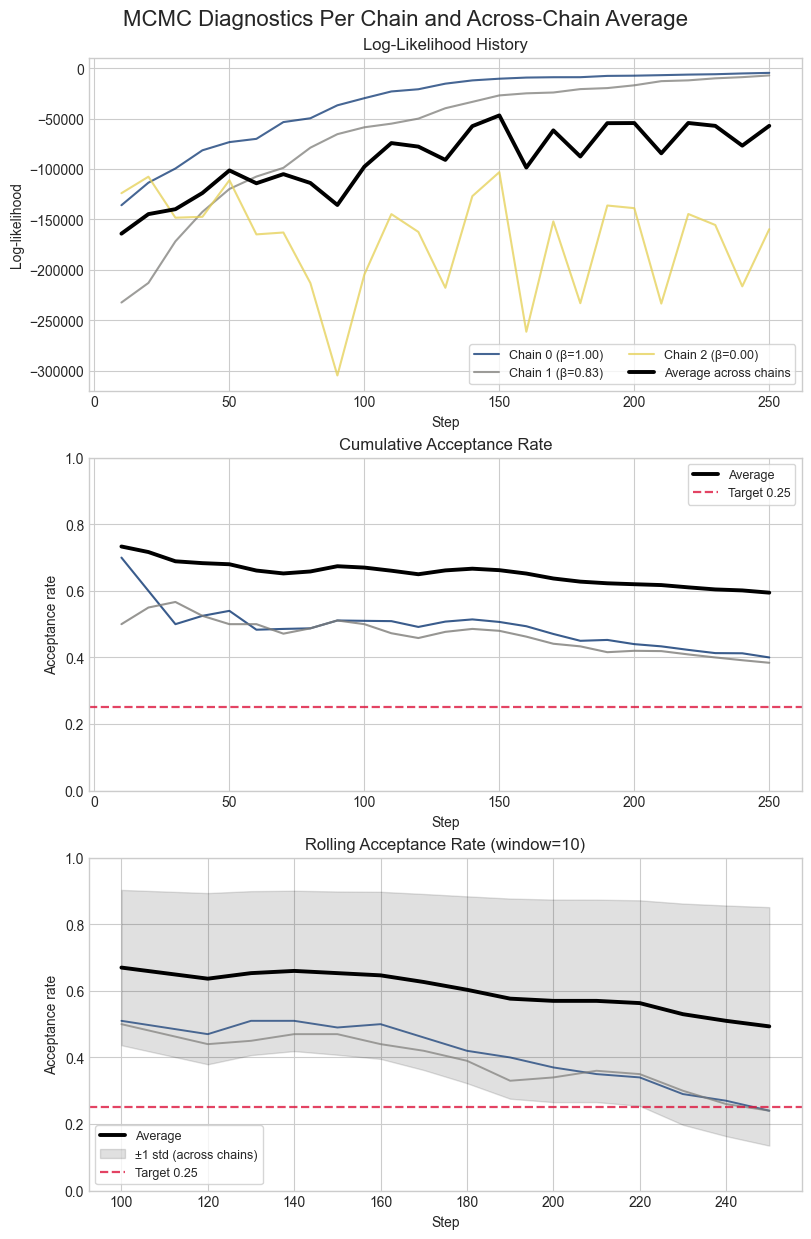

In [ ]:
# ------------------------------------------------------------
# Uses output from:
# n_steps_iter_state, n_steps_history = step_n_chains(...)
# ------------------------------------------------------------
history_iterations = n_steps_history.iterations
history_states = n_steps_history.states
history_n_accepted = n_steps_history.iterand_n_accepted
history_iter_accepted = n_steps_history.states_accepted

# Extract arrays
logL = np.asarray(history_states.log_likelihood).astype(float)
n_acc = np.asarray(history_n_accepted).astype(float)   # accepted count in each kept block
iter_acc = np.asarray(history_iter_accepted).astype(float)  # last proposal accepted (0/1)
betas = np.asarray(tuned_chains.beta, dtype=float)

# Normalize orientation to (n_chains, n_saved)
n_chains = int(betas.shape[0])

def to_chain_time(arr, name):
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"{name} must be 2D, got shape={arr.shape}")
    if arr.shape[0] == n_chains:
        return arr
    if arr.shape[1] == n_chains:
        return arr.T
    raise ValueError(f"Could not infer chain axis for {name}. shape={arr.shape}, n_chains={n_chains}")

logL = to_chain_time(logL, "logL")
n_acc = to_chain_time(n_acc, "history_n_accepted")
iter_acc = to_chain_time(iter_acc, "history_iter_accepted")

n_saved = logL.shape[1]
if n_acc.shape[1] != n_saved or iter_acc.shape[1] != n_saved:
    raise ValueError(
        f"History length mismatch: logL={logL.shape}, n_acc={n_acc.shape}, iter_acc={iter_acc.shape}"
    )

# Build x-axis from history_iterations robustly
iters_raw = np.asarray(history_iterations)
if iters_raw.ndim == 1:
    steps = iters_raw.astype(int)
elif iters_raw.ndim == 2:
    if iters_raw.shape == (n_chains, n_saved):
        steps = np.asarray(iters_raw[0], dtype=int)
    elif iters_raw.shape == (n_saved, n_chains):
        steps = np.asarray(iters_raw[:, 0], dtype=int)
    else:
        raise ValueError(f"Unexpected history_iterations shape={iters_raw.shape}")
else:
    raise ValueError(f"history_iterations must be 1D or 2D, got shape={iters_raw.shape}")

if steps.shape[0] != n_saved:
    raise ValueError(f"steps length mismatch: len(steps)={len(steps)}, n_saved={n_saved}")

# Attempts per kept point (usually keep_interval)
block_sizes = np.diff(np.concatenate(([0], steps))).astype(float)
if np.any(block_sizes <= 0):
    raise ValueError(f"Non-increasing history_iterations found: {steps}")

# Per-kept-block acceptance rate (proposal-level)
accept = n_acc / block_sizes[None, :]

# Metrics
# IMPORTANT: cumulative_rate must stay per-chain (2D), not collapsed over chains
cumulative_accepts = np.cumsum(n_acc, axis=1)
cumulative_attempts = np.cumsum(np.broadcast_to(block_sizes, (n_chains, n_saved)), axis=1)
cumulative_rate = cumulative_accepts / cumulative_attempts

window = min(75, max(10, n_saved // 20))
window = min(window, n_saved)
window = max(window, 1)

kernel = np.ones(window, dtype=float)
rolling_num = np.array([np.convolve(n_acc[i], kernel, mode="valid") for i in range(n_chains)])
rolling_den = np.convolve(block_sizes, kernel, mode="valid")
rolling_rate = rolling_num / rolling_den[None, :]
rolling_steps = steps[window - 1 :]

# Averages across chains
avg_logL = np.mean(logL, axis=0)
avg_cum_rate = np.mean(cumulative_rate, axis=0)
avg_rolling = np.mean(rolling_rate, axis=0)
std_rolling = np.std(rolling_rate, axis=0)

# Style
plt.style.use("seaborn-v0_8-whitegrid")
colors = plt.cm.cividis(np.linspace(0.1, 0.9, n_chains))

fig, axes = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

# Log-likelihood history
ax = axes[0]
for i in range(n_chains):
    ax.plot(
        steps, logL[i], color=colors[i], lw=1.5, alpha=0.75,
        label=f"Chain {i} (β={betas[i]:.2f})"
    )
ax.plot(steps, avg_logL, color="black", lw=2.8, label="Average across chains")
ax.set_title("Log-Likelihood History")
ax.set_xlabel("Step")
ax.set_ylabel("Log-likelihood")
ax.legend(frameon=True, fontsize=9, ncol=2)

# Cumulative acceptance rate
ax = axes[1]
for i in range(n_chains):
    ax.plot(steps, cumulative_rate[i], color=colors[i], lw=1.5, alpha=0.8)
ax.plot(steps, avg_cum_rate, color="black", lw=2.8, label="Average")
ax.axhline(0.25, color="crimson", ls="--", lw=1.6, alpha=0.8, label="Target 0.25")
ax.set_title("Cumulative Acceptance Rate")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=True, fontsize=9)

# Rolling acceptance rate
ax = axes[2]
for i in range(n_chains):
    ax.plot(rolling_steps, rolling_rate[i], color=colors[i], lw=1.4, alpha=0.7)
ax.plot(rolling_steps, avg_rolling, color="black", lw=2.8, label="Average")
ax.fill_between(
    rolling_steps,
    np.clip(avg_rolling - std_rolling, 0, 1),
    np.clip(avg_rolling + std_rolling, 0, 1),
    color="black",
    alpha=0.12,
    label="±1 std (across chains)"
)
ax.axhline(0.25, color="crimson", ls="--", lw=1.6, alpha=0.8, label="Target 0.25")
ax.set_title(f"Rolling Acceptance Rate (window={window})")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=True, fontsize=9)

fig.suptitle("MCMC Diagnostics Per Chain and Across-Chain Average", fontsize=16, y=1.02)
plt.show()

In [ ]:
# ------------------------------------------------------------------
# Input expected from:
# n_steps_iter_state, n_steps_history = step_n_chains(...)
# ------------------------------------------------------------------
history_iterations, history_states, history_n_accepted, history_iter_accepted = n_steps_history

logL = np.asarray(history_states.log_likelihood).astype(float)
n_acc = np.asarray(history_n_accepted).astype(float)          # accepted proposals per kept block
iter_acc = np.asarray(history_iter_accepted).astype(float)    # last proposal accepted in block (0/1)

betas = np.asarray(tuned_chains.beta, dtype=float)
step_sizes = np.asarray(tuned_chains.proposal_dist.step_size, dtype=float)

n_chains = int(betas.shape[0])

if step_sizes.ndim == 0:
    step_sizes = np.full(n_chains, float(step_sizes))


def to_chain_time(arr, name):
    arr = np.asarray(arr)
    if arr.ndim != 2:
        raise ValueError(f"{name} must be 2D, got shape={arr.shape}")
    if arr.shape[0] == n_chains:
        return arr
    if arr.shape[1] == n_chains:
        return arr.T
    raise ValueError(f"Could not infer chain axis for {name}. shape={arr.shape}, n_chains={n_chains}")


logL = to_chain_time(logL, "logL")
n_acc = to_chain_time(n_acc, "history_n_accepted")
iter_acc = to_chain_time(iter_acc, "history_iter_accepted")

n_saved = logL.shape[1]
if n_acc.shape[1] != n_saved or iter_acc.shape[1] != n_saved:
    raise ValueError(
        f"History length mismatch: logL={logL.shape}, n_acc={n_acc.shape}, iter_acc={iter_acc.shape}"
    )

# Build x-axis from stored kept-iteration indices
iters_raw = np.asarray(history_iterations)
if iters_raw.ndim == 1:
    steps = iters_raw.astype(int)
elif iters_raw.ndim == 2:
    if iters_raw.shape == (n_chains, n_saved):
        steps = np.asarray(iters_raw[0], dtype=int)
    elif iters_raw.shape == (n_saved, n_chains):
        steps = np.asarray(iters_raw[:, 0], dtype=int)
    else:
        raise ValueError(f"Unexpected history_iterations shape={iters_raw.shape}")
else:
    raise ValueError(f"history_iterations must be 1D or 2D, got shape={iters_raw.shape}")

if steps.shape[0] != n_saved:
    raise ValueError(f"steps length mismatch: len(steps)={len(steps)}, n_saved={n_saved}")

# Attempts per kept block (typically keep_interval)
block_sizes = np.diff(np.concatenate(([0], steps))).astype(float)
if np.any(block_sizes <= 0):
    raise ValueError(f"Non-increasing history_iterations found: {steps}")

# Proposal-level acceptance rate per kept block
accept_rate = n_acc / block_sizes[None, :]

# Acceptance metrics
cumulative_accepts = np.cumsum(n_acc, axis=1)
cumulative_attempts = np.cumsum(np.broadcast_to(block_sizes, (n_chains, n_saved)), axis=1)
cumulative_rate = cumulative_accepts / cumulative_attempts

window = min(75, max(10, n_saved // 20))
window = min(window, n_saved)
window = max(window, 1)

kernel = np.ones(window, dtype=float)
rolling_num = np.array([np.convolve(n_acc[i], kernel, mode="valid") for i in range(n_chains)])
rolling_den = np.convolve(block_sizes, kernel, mode="valid")
rolling_rate = rolling_num / rolling_den[None, :]
rolling_steps = steps[window - 1 :]

# Cross-chain summaries
avg_logL = np.mean(logL, axis=0)
avg_cum_accepts = np.mean(cumulative_accepts, axis=0)
avg_cum_rate = np.mean(cumulative_rate, axis=0)
avg_rolling = np.mean(rolling_rate, axis=0)
std_rolling = np.std(rolling_rate, axis=0)

# ACF only for log-likelihood
if n_saved < 2:
    raise ValueError("Need at least 2 saved points to compute ACF.")
alpha = 0.05
max_lag = min(250, max(20, n_saved // 4), n_saved - 1)
lags = np.arange(max_lag + 1)

acf_logL = []
ci0_logL = []  # zero-centered CI
for i in range(n_chains):
    a, ci = acf(logL[i], nlags=max_lag, fft=True, alpha=alpha, bartlett_confint=True)
    acf_logL.append(a)
    ci0_logL.append(ci - a[:, None])

acf_logL = np.asarray(acf_logL)
ci0_logL = np.asarray(ci0_logL)

avg_acf_logL = acf_logL.mean(axis=0)
avg_low_logL = ci0_logL[:, :, 0].mean(axis=0)
avg_high_logL = ci0_logL[:, :, 1].mean(axis=0)

# Labels per chain
mean_block_rate = accept_rate.mean(axis=1)
chain_labels = [
    f"Chain {i} | β={betas[i]:.3g}, s={step_sizes[i]:.3g}, acc={mean_block_rate[i]:.3f}"
    for i in range(n_chains)
]

# Plot styling
plt.style.use("seaborn-v0_8-whitegrid")
colors = plt.cm.cividis(np.linspace(0.1, 0.9, n_chains))

fig, axes = plt.subplots(3, 2, figsize=(10, 8), constrained_layout=True)

# 1) Log-likelihood traces
ax = axes[0, 0]
for i in range(n_chains):
    ax.plot(steps, logL[i], color=colors[i], lw=1.3, alpha=0.8, label=chain_labels[i])
ax.plot(steps, avg_logL, color="black", lw=2.8, label="Average")
ax.set_title("Log-Likelihood History")
ax.set_xlabel("Step")
ax.set_ylabel("Log-likelihood")
ax.legend(frameon=True, fontsize=8, ncol=1)

# 2) Cumulative accepts
ax = axes[0, 1]
for i in range(n_chains):
    ax.plot(steps, cumulative_accepts[i], color=colors[i], lw=1.3, alpha=0.85, label=chain_labels[i])
ax.plot(steps, avg_cum_accepts, color="black", lw=2.8, label="Average")
ax.set_title("Cumulative Accepted Proposals")
ax.set_xlabel("Step")
ax.set_ylabel("Accepted count")
ax.legend(frameon=True, fontsize=8, ncol=1)

# 3) Cumulative acceptance rate
ax = axes[1, 0]
for i in range(n_chains):
    ax.plot(steps, cumulative_rate[i], color=colors[i], lw=1.3, alpha=0.85, label=chain_labels[i])
ax.plot(steps, avg_cum_rate, color="black", lw=2.8, label="Average")
ax.axhline(0.25, color="crimson", ls="--", lw=1.5, alpha=0.9, label="Target 0.25")
ax.set_title("Cumulative Acceptance Rate")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=True, fontsize=8, ncol=1)

# 4) Rolling acceptance rate
ax = axes[1, 1]
for i in range(n_chains):
    ax.plot(rolling_steps, rolling_rate[i], color=colors[i], lw=1.2, alpha=0.8, label=chain_labels[i])
ax.plot(rolling_steps, avg_rolling, color="black", lw=2.8, label="Average")
ax.fill_between(
    rolling_steps,
    np.clip(avg_rolling - std_rolling, 0, 1),
    np.clip(avg_rolling + std_rolling, 0, 1),
    color="black",
    alpha=0.12,
    label="±1 std across chains",
)
ax.axhline(0.25, color="crimson", ls="--", lw=1.5, alpha=0.9, label="Target 0.25")
ax.set_title(f"Rolling Acceptance Rate (window={window})")
ax.set_xlabel("Step")
ax.set_ylabel("Acceptance rate")
ax.set_ylim(0.0, 1.0)
ax.legend(frameon=True, fontsize=8, ncol=1)

# 5) ACF of log-likelihood with statsmodels bounds
ax = axes[2, 0]
for i in range(n_chains):
    ax.plot(lags, acf_logL[i], color=colors[i], lw=1.2, alpha=0.8, label=chain_labels[i])
ax.plot(lags, avg_acf_logL, color="black", lw=2.8, label="Average ACF")
ax.fill_between(
    lags, avg_low_logL, avg_high_logL,
    color="gray", alpha=0.18,
    label=f"{int((1-alpha)*100)}% CI (statsmodels/Bartlett)",
)
ax.plot(lags, avg_high_logL, color="gray", ls="--", lw=1.0, alpha=0.9)
ax.plot(lags, avg_low_logL, color="gray", ls="--", lw=1.0, alpha=0.9)
ax.axhline(0.0, color="gray", lw=1.0)
ax.set_title("Autocorrelation: Log-Likelihood")
ax.set_xlabel("Lag")
ax.set_ylabel("ACF")
ax.set_ylim(-0.2, 1.05)
ax.legend(frameon=True, fontsize=8, ncol=1)

# 6) Legend/info panel
ax = axes[2, 1]
ax.axis("off")
info_lines = [
    f"{i}: β={betas[i]:.6g}, s={step_sizes[i]:.6g}, mean_acc={mean_block_rate[i]:.4f}, last_acc={iter_acc[i, -1]:.0f}"
    for i in range(n_chains)
]
ax.text(
    0.0, 1.0,
    "Chain Index Map\n\n" + "\n".join(info_lines),
    va="top", ha="left", fontsize=11, family="monospace"
)

fig.suptitle("Per-Chain MCMC Diagnostics (indexed by temperature and step size)", fontsize=17, y=1.03)
plt.show()

TypeError: cannot unpack non-iterable History object

# PT

In [18]:
# ----------------------------
# Configuration
# ----------------------------
N_chains = 16

N_steps_pre_burn_in = 500
N_steps_tune = 1000
N_steps = 1200

tune_interval = 200
keep_interval = 10
window = 75

step_size_min = 0.03
step_size_max = 0.2

target_chain_acceptance = 0.25
target_swap_acceptance = 0.25

learning_rate_step_size=0.9
# learning_rate_step_size=0.3
learning_rate_step_size_decay=0.75
learning_rate_beta=0.05
learning_rate_beta_decay=0.75

betas = initialize_betas(n_chains=N_chains, base=1.3, last_is_zero=False)
print(f"{betas=}")
step_sizes = jnp.linspace(step_size_min, step_size_max, N_chains)

# ----------------------------
# Build vectorized chains
# ----------------------------

proposal_dist = ProposalDistribution(dist=prior, step_size=step_sizes)
chain_template = ExtendedMetropolisChain(
    beta=1.0,
    proposal_dist=proposal_dist,          # from notebook setup
    forward_model=forward_model,          # from notebook setup
    log_likelihood_fn=log_likelihood_gaussian,
)

chain_spec = make_pytree_spec(
    chain_template,
    {
        "beta": 0,
        "proposal_dist.step_size": 0,
        "*": None,
    },
)

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(0, 0), out_axes=chain_spec)
def make_chain(beta, step):
    return ExtendedMetropolisChain(
        beta=beta,
        proposal_dist=ProposalDistribution(dist=prior, step_size=step),
        forward_model=forward_model,
        log_likelihood_fn=log_likelihood_gaussian,
    )

chains = make_chain(betas, step_sizes)

@eqx.filter_jit
@eqx.filter_vmap(in_axes=(0, chain_spec, None))
def init_state(k, c, obs_):
    return c.get_iteration_state(prior(k), obs_)

betas=Array([1.        , 0.7692308 , 0.591716  , 0.4551662 , 0.35012785,
       0.26932913, 0.20717625, 0.15936635, 0.12258951, 0.09429963,
       0.07253817, 0.0557986 , 0.042922  , 0.03301692, 0.02539764,
       0.01953664], dtype=float32)


In [19]:
# Single-cell PT setup + tune + production run (no extra burn-in)


iter_states0 = init_state(skey(n=N_chains), chains, obs)

pt = ParallelTemperingSampler(chains=chains, chain_axes_spec=chain_spec)

# Pre-burn-in PT
iter_states_burnt_in, pre_burn_in_history = pt.step_n(
    N_steps_pre_burn_in,
    key=skey(),
    iter_states=iter_states0,
    observations=obs,
    progress=PROGRESS,
    keep_interval=keep_interval,
)

PT Sampling:   0%|          | 0/500 [00:00<?, ?it/s]

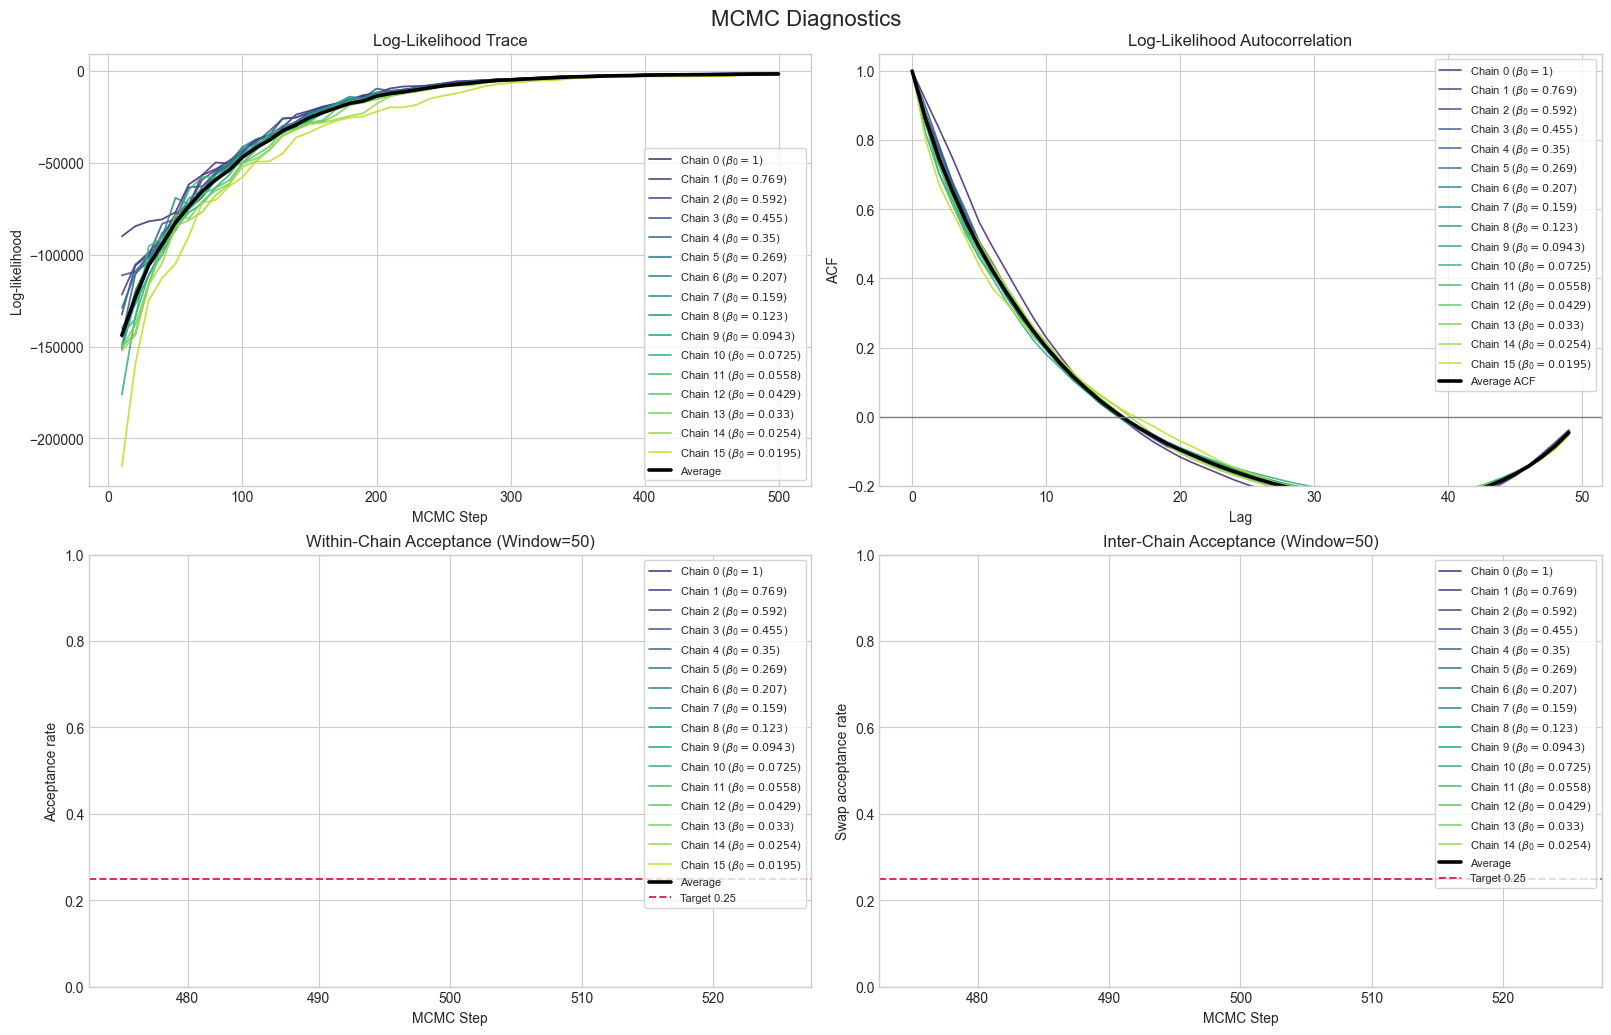

(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Log-Likelihood Trace'}, xlabel='MCMC Step', ylabel='Log-likelihood'>,
         <Axes: title={'center': 'Log-Likelihood Autocorrelation'}, xlabel='Lag', ylabel='ACF'>],
        [<Axes: title={'center': 'Within-Chain Acceptance (Window=50)'}, xlabel='MCMC Step', ylabel='Acceptance rate'>,
         <Axes: title={'center': 'Inter-Chain Acceptance (Window=50)'}, xlabel='MCMC Step', ylabel='Swap acceptance rate'>]],
       dtype=object))

In [20]:
pre_burn_in_history.plot_diagnostics()

In [21]:
# # Tune temperature and step-sizes jointly
# pt_tuned, iter_states_tuned, tune_history = pt.tune(
#     n_steps_tune=N_steps_tune,
#     tune_interval=tune_interval,
#     key=skey(),
#     iter_states=iter_states_burnt_in,
#     observations=obs,
#     initial_step_size=step_sizes,
#     initial_betas=betas,
#     target_chain_acceptance_rate=target_chain_acceptance,
#     target_swap_acceptance_rate=target_swap_acceptance,
#     learning_rate_step_size=learning_rate_step_size,
#     learning_rate_step_size_decay=learning_rate_step_size_decay,
#     learning_rate_beta=learning_rate_beta,
#     learning_rate_beta_decay=learning_rate_beta_decay,
#     keep_interval=keep_interval,
#     progress=PROGRESS,
# )



In [22]:
# # Tune step-sizes only
pt_tuned, iter_states_tuned, tune_history = pt.tune_step_sizes(
    n_steps_tune=N_steps_tune,
    tune_interval=tune_interval,
    key=skey(),
    iter_states=iter_states_burnt_in,
    observations=obs,
    initial_step_size=step_sizes,
    target_chain_acceptance_rate=target_chain_acceptance,
    learning_rate=learning_rate_step_size,
    learning_rate_decay=learning_rate_step_size_decay,
    keep_interval=keep_interval,
    progress=PROGRESS,
)



PT Step Tuning:   0%|          | 0/1000 [00:00<?, ?it/s]

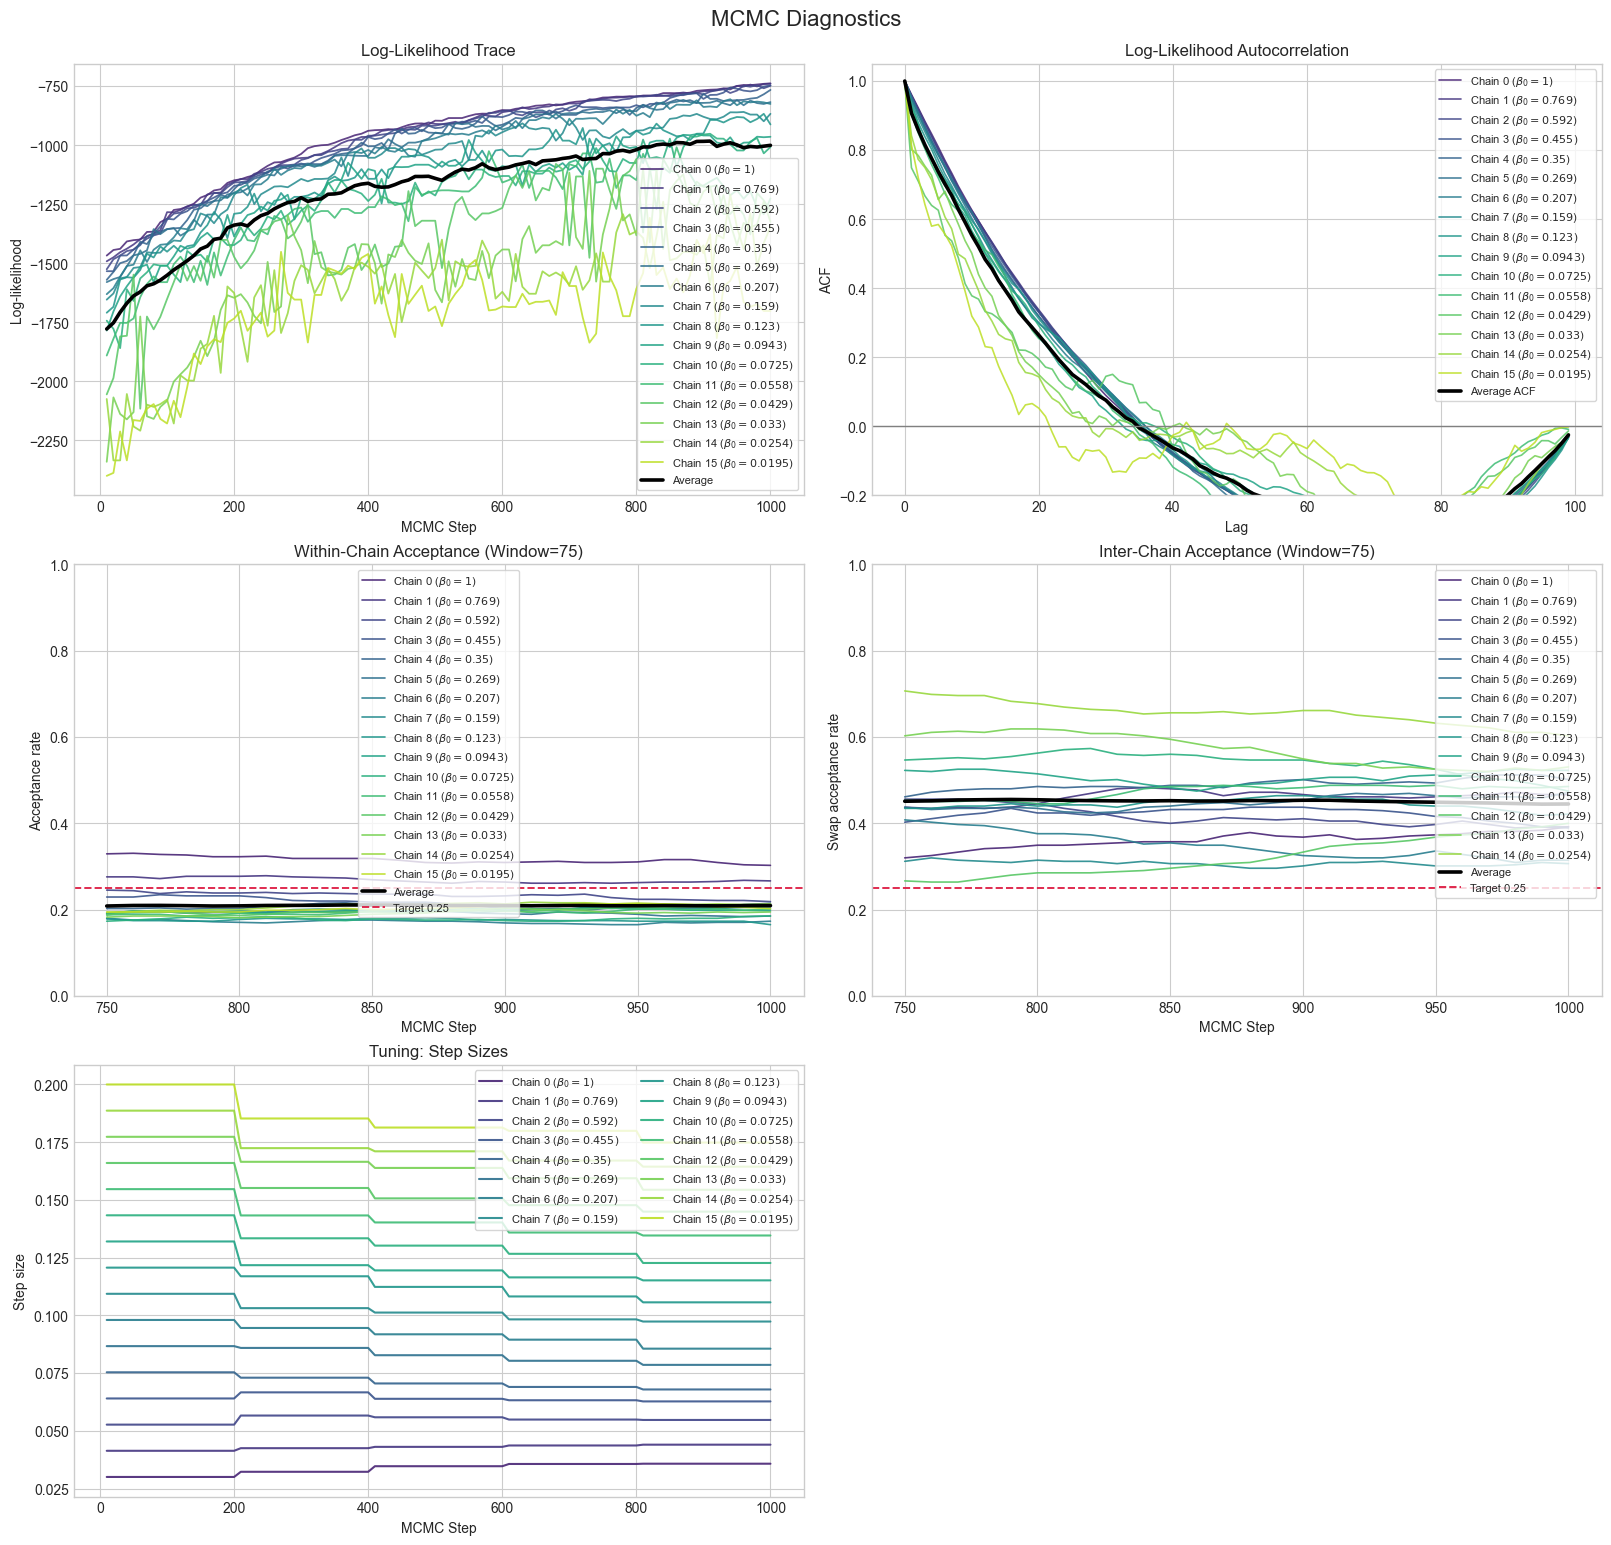

Ellipsis

In [27]:
tune_history.plot_diagnostics()
...

In [28]:
# ----------------------------
# Production run (start from tuned state; no extra burn-in)
# ----------------------------

iter_states_samples, samples_history = pt_tuned.step_n(
    n=N_steps,
    key=skey(),
    iter_states=iter_states_tuned,
    observations=obs,
    progress=PROGRESS,
    keep_interval=keep_interval,
)

PT Sampling:   0%|          | 0/1200 [00:00<?, ?it/s]

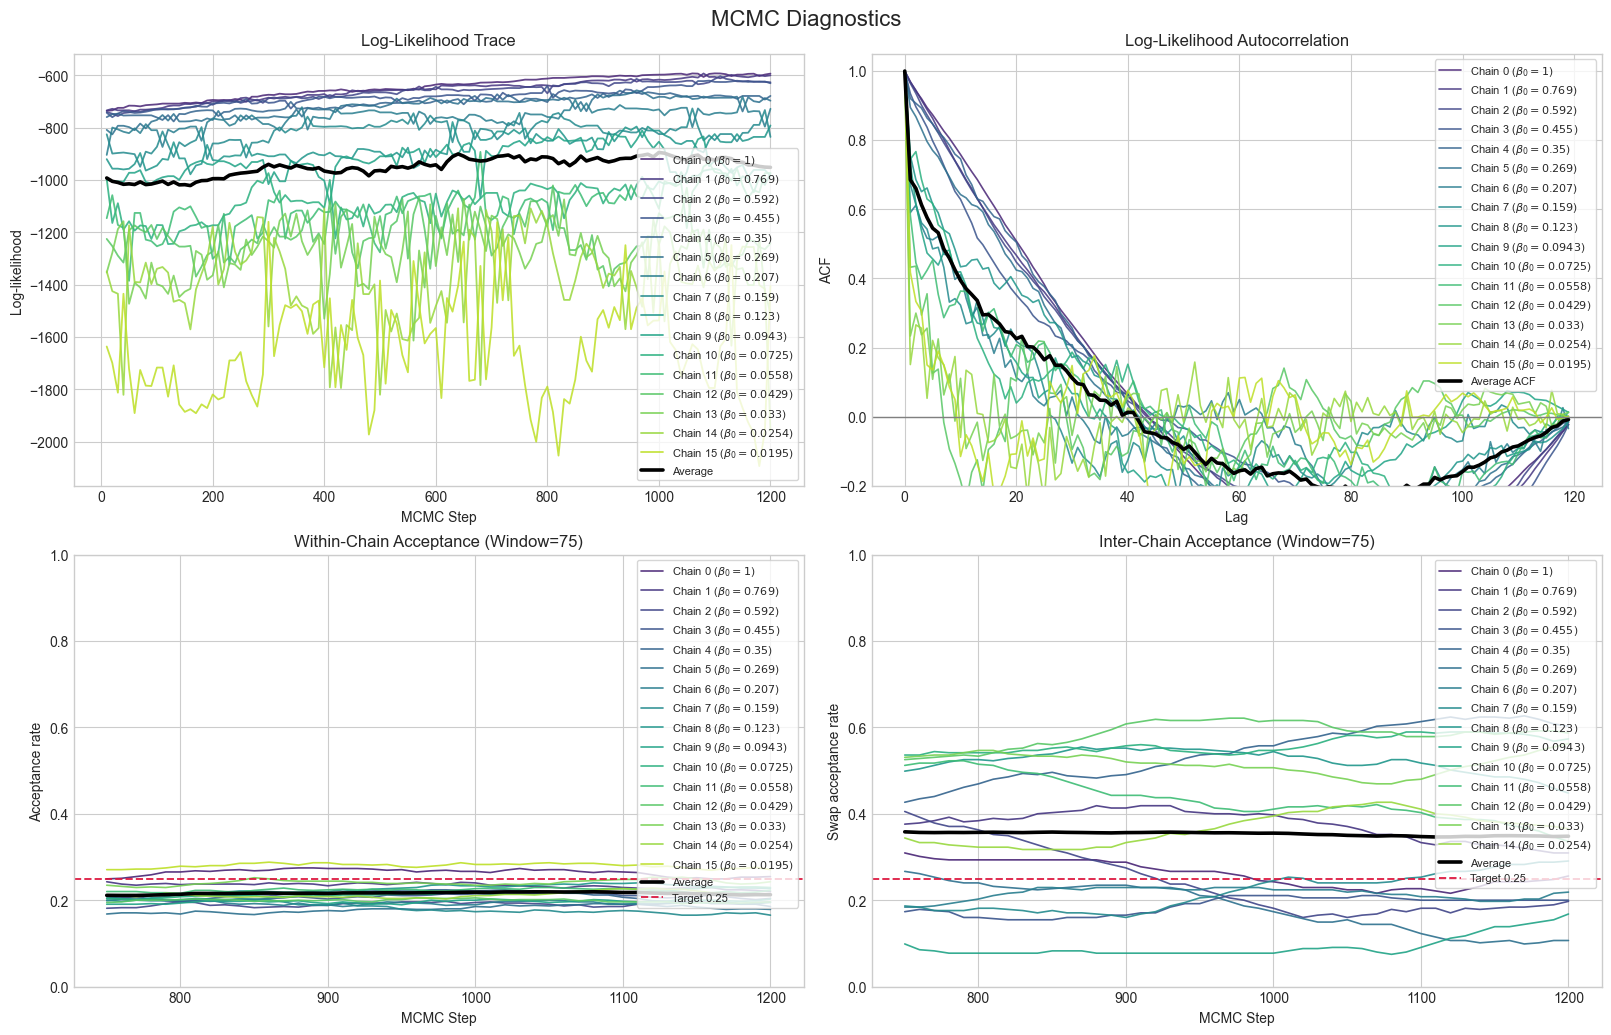

(<Figure size 1600x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'Log-Likelihood Trace'}, xlabel='MCMC Step', ylabel='Log-likelihood'>,
         <Axes: title={'center': 'Log-Likelihood Autocorrelation'}, xlabel='Lag', ylabel='ACF'>],
        [<Axes: title={'center': 'Within-Chain Acceptance (Window=75)'}, xlabel='MCMC Step', ylabel='Acceptance rate'>,
         <Axes: title={'center': 'Inter-Chain Acceptance (Window=75)'}, xlabel='MCMC Step', ylabel='Swap acceptance rate'>]],
       dtype=object))

In [29]:
samples_history.plot_diagnostics()